# Generate Stand-to-Sit Cam

Generates the stand-to-sit (st2si) transmission cam profile that pairs with
a previously generated sit-to-stand cam and storage cam (loaded from
`results/cams/cams_<date>_K=<k>/`), using `CamGeneration.generate_sit_cam`
from [class_cam_generation.py](class_cam_generation.py).

Given existing sit-to-stand transmission and storage cam point clouds in 
Cartesian form, this notebook solves for a stand-to-sit cam shape and then
computes/plots the cable force curves for both the stand-to-sit and
sit-to-stand directions as a consistency check.

**Outputs:** the generated stand-to-sit transmission cam points (optionally\
saved to `results/cams/cams_<date>/st2si_points/`), and
force-vs-stance-percentage plots for both cam directions.

# Startup

In [ ]:
from importlib import reload
from datetime import date
from pathlib import Path
import numpy as np
import pandas as pd
import class_cam_generation

# Choose whether and where to save the cam as a .txt file.
save = True
dateStr = date.today().strftime("%Y-%m-%d")
save_dir = str(Path('results/cams/cams_' + dateStr))    

# Load point clouds for a specific sit-to-stand transmission cam and storage
# cam in Cartesian coordinates and convert from millimeters to meters.
folder_path = 'results/cams/cams_2024-06-13_K=100/'
cam_idx = 63
pts_si2st = np.array(pd.read_csv(f'{folder_path}inner_{cam_idx}.txt',
                                 header=None, usecols=[0,1])) / 1000
pts_stor = np.array(pd.read_csv(f'{folder_path}outer_{cam_idx}.txt',
                                header=None, usecols=[0,1])) / 1000

# Define problem parameters.
# k: spring stiffness in N/m
# sit_angle_deg: angle of the cam in degrees when the user is sitting
# offset_angle_deg: angle of transmission vs. storage cams in degrees
k = 100
sit_angle_deg = 220
offset_angle_deg = 180

# CamGeneration requires gear_ratios, input_angles, and scaling at
# construction, but this notebook only uses the resulting object for its
# to_polar/generate_sit_cam methods (not the cam shape those arguments would
# produce), so placeholder values are sufficient here.
x = np.ones(17)
gear_ratios = x[: 8]
input_angles = x[8 : -1]
scaling = x[-1]

# Optimization

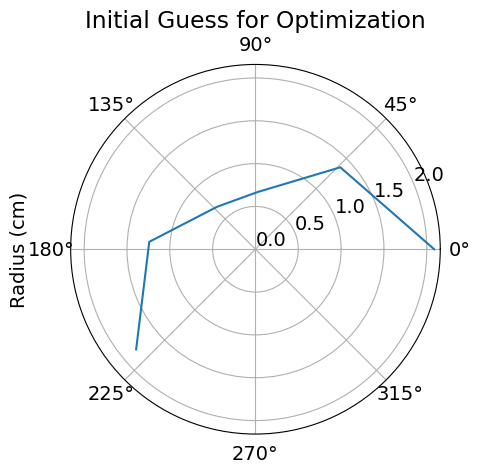

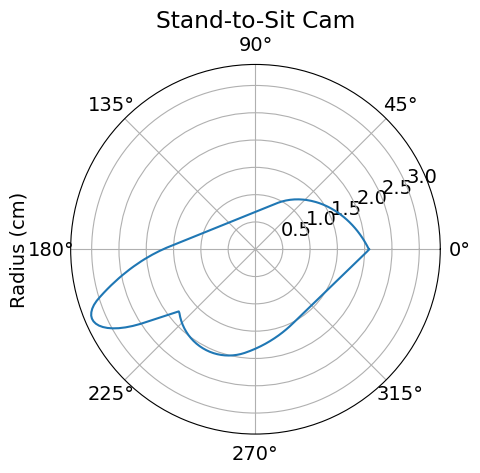

In [2]:
# Create CamGeneration object.
reload(class_cam_generation)
from class_cam_generation import CamGeneration
Cam = CamGeneration(gear_ratios, input_angles, scaling,
                    sit_angle=np.deg2rad(sit_angle_deg),
                    offset_angle=np.deg2rad(offset_angle_deg))

# Convert Cartesian point cloud to polar coordinates.
r_si2st, ang_si2st = Cam.to_polar(pts_si2st)
r_stor, ang_stor = Cam.to_polar(pts_stor)

# Generate stand-to-sit transmission cam.
result, r_st2si, x_trans_st2si, r_st2si_cart = Cam.generate_sit_cam(r_si2st,
                                                                    ang_si2st,
                                                                    r_stor, k,
                                                                    n_params=6)

In [3]:
# Save generated stand-to-sit transmission cam Cartesian points in millimeters
# to a .txt file if save=True.
if save:
    filepath = Path('results/cams/cams_' + dateStr + '/st2si_points')
    filepath.mkdir(parents=True, exist_ok=True)
    file_st2si = filepath / f'st2si_{cam_idx}.txt'
    np.savetxt(str(file_st2si), np.append(r_st2si_cart * 1000,
                                    np.zeros((r_st2si_cart.shape[0], 1)),
                                    axis=1), delimiter=',')

# Visualization

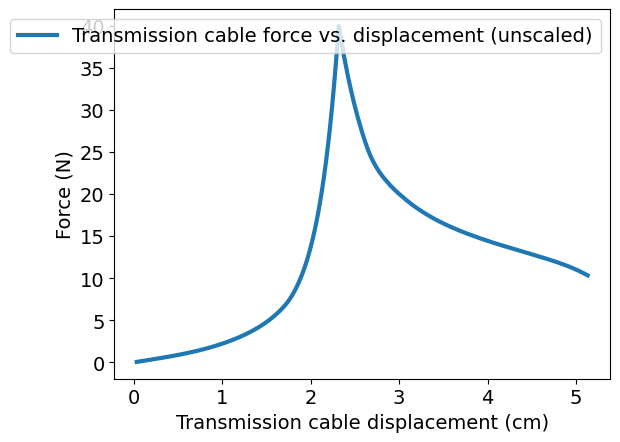

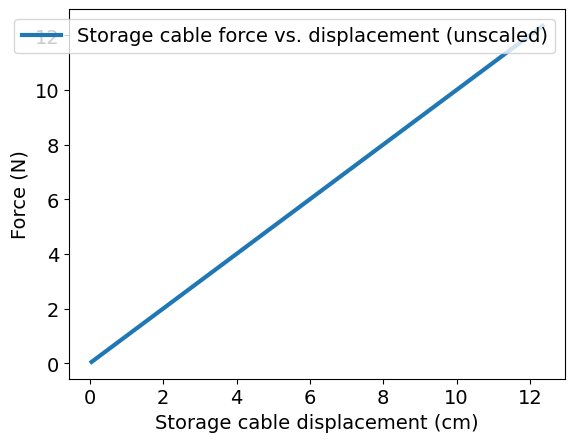

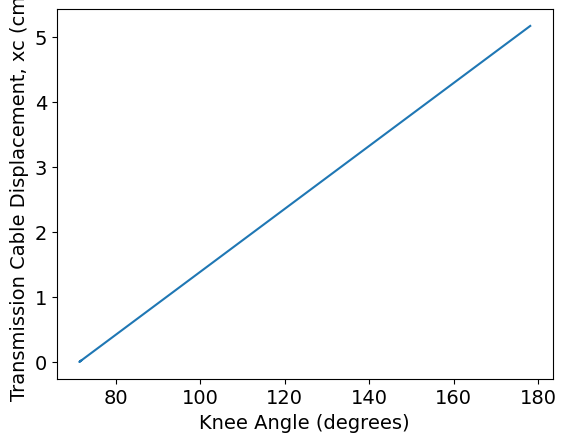

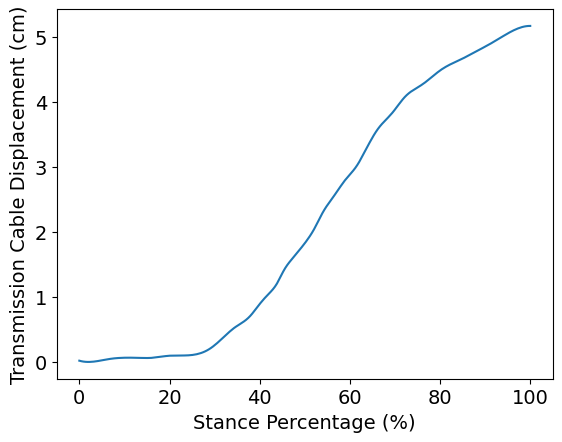

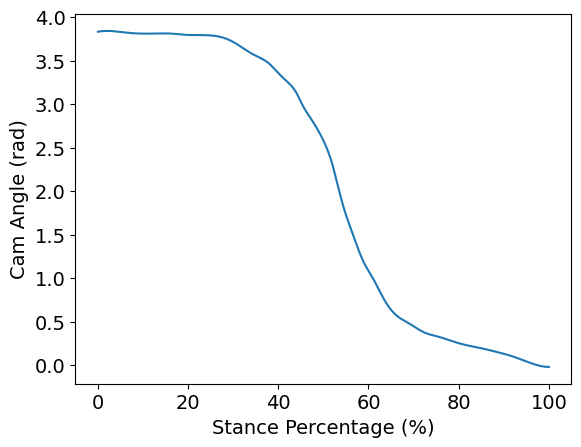

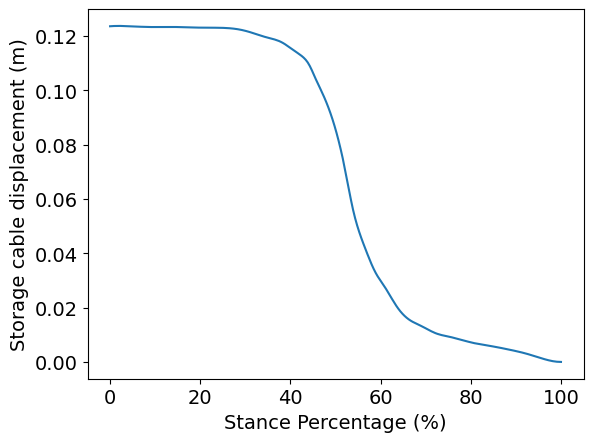

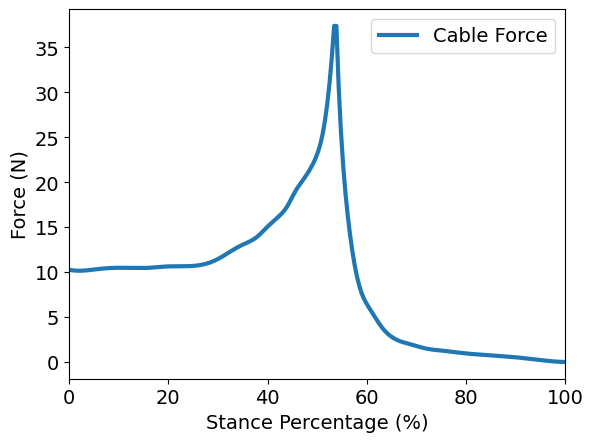

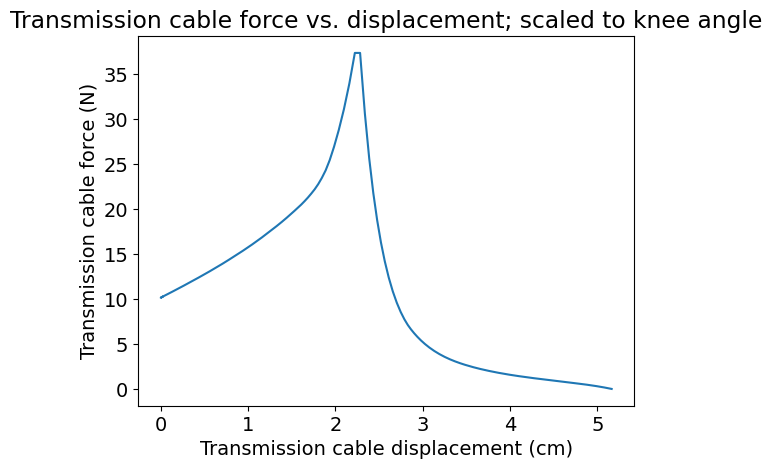

In [4]:
# Put stand-to-sit cam and outer cam shapes together in an array.
r_dual_st2si = np.vstack((r_st2si, r_stor)).T

# Calculate force vs. stance percentage for the stand-to-sit cam.
plot = True
index = cam_idx
forces, percentages = Cam.calc_forces(r_dual_st2si, x_trans_st2si,
                                      k, torque=False, plot=plot, save=save,
                                      save_dir=save_dir, index=index)

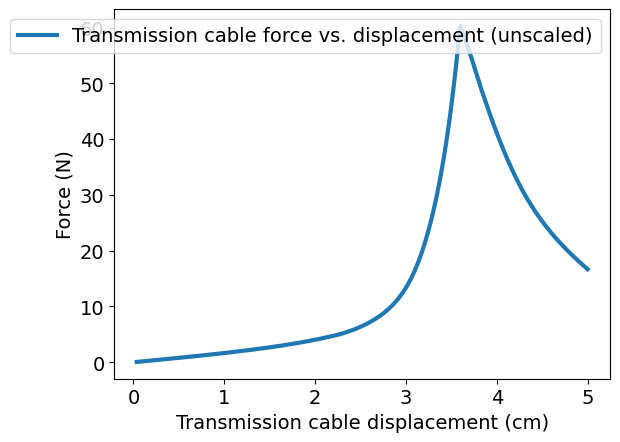

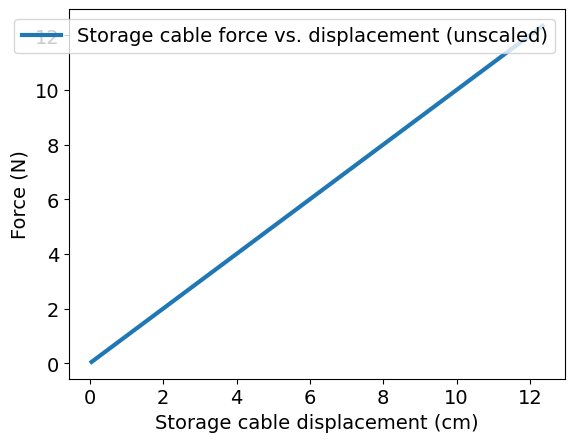

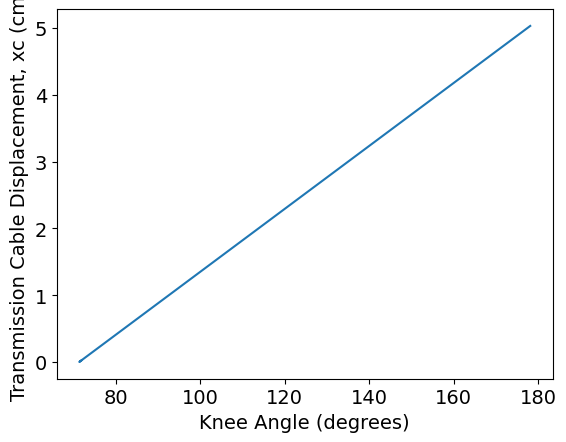

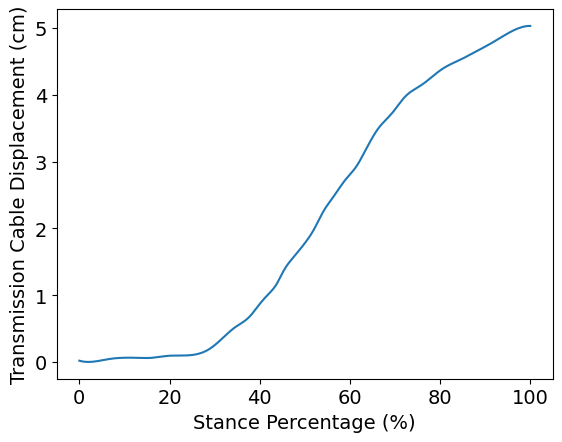

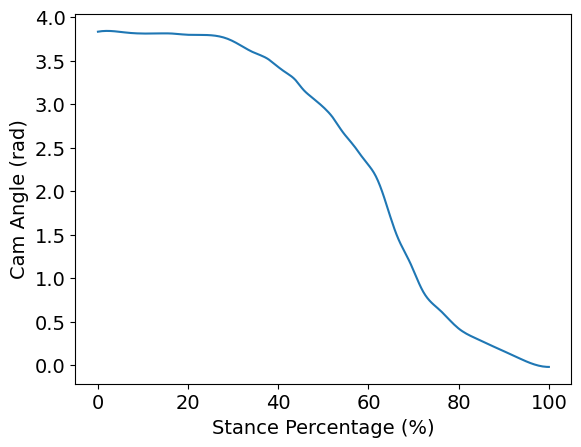

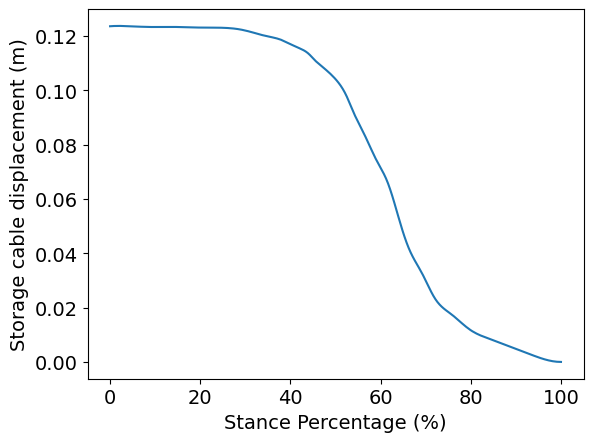

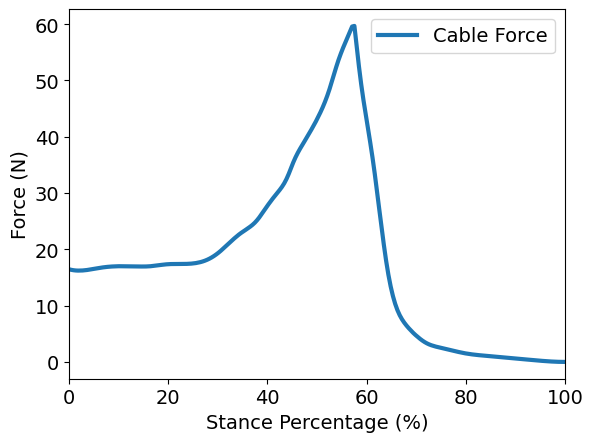

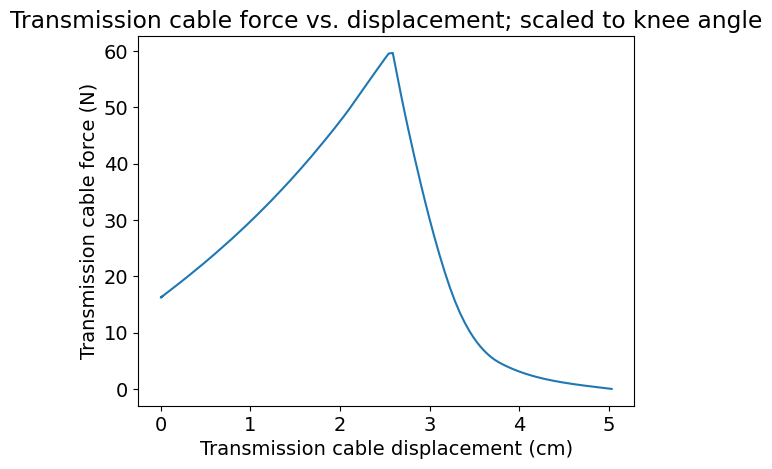

In [5]:
# Check energy release in sit-to-stand cam
r_dual_si2st = np.vstack((r_si2st, r_stor)).T
x_trans_si2st = np.cumsum(np.deg2rad(r_si2st))
plot = True
index = cam_idx
forces, percentages = Cam.calc_forces(r_dual_si2st, x_trans_si2st, k,
                                      torque=False, plot=plot, save=save, 
                                      save_dir=save_dir, index=index)
